# Mobile Money Fraud Detection — Rwanda
## Objectives
1. Collect & preprocess mobile money transaction data
2. Extract relevant features (patterns, user behaviour, location)
3. Train SVM, Random Forest, Gradient Boosting (+ XGBoost, LightGBM, Naïve Bayes)
4. Evaluate with Accuracy, Precision, Recall, F1, ROC-AUC
5. Integrate real-time fraud alerts with face verification
6. Compare all models and select the best for deployment

## Phase 1 — Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time, warnings, json, os
import joblib
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, ConfusionMatrixDisplay, f1_score,
    accuracy_score, precision_score, recall_score
)
from imblearn.over_sampling import SMOTE

from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from xgboost import XGBClassifier
import lightgbm as lgb

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)
plt.rcParams["figure.dpi"] = 100
sns.set_style("whitegrid")

# ── Make sure notebook working directory = project folder ──────────────────
# This prevents a second .db from being created in the wrong folder
import os
notebook_dir = os.path.dirname(os.path.abspath("Momo_Clean.ipynb"))
os.chdir(notebook_dir)
print("Working directory:", os.getcwd())
print("All libraries loaded successfully.")

Working directory: d:\mobile_money_fraud_detection
All libraries loaded successfully.


## Phase 2 — Load & Sample Data (Objective 1)

In [2]:
df_raw = pd.read_csv("Fraud.csv", nrows=500_000)
df_raw.columns = df_raw.columns.str.strip()

# Stratified sample — preserves the rare fraud class ratio
df = (
    df_raw.groupby("isFraud", group_keys=False)
    .sample(frac=0.4, random_state=42)
    .reset_index(drop=True)
)

print(f"Full dataset shape   : {df_raw.shape}")
print(f"Sampled dataset shape: {df.shape}")
print("\nClass distribution after sampling:")
print(df["isFraud"].value_counts())
print("\nFraud percentage:", round(df["isFraud"].mean() * 100, 3), "%")

Full dataset shape   : (500000, 11)
Sampled dataset shape: (200000, 11)

Class distribution after sampling:
isFraud
0    199907
1        93
Name: count, dtype: int64

Fraud percentage: 0.046 %


## Phase 3 — Exploratory Data Analysis (Objective 1)

In [3]:
print("Shape:", df.shape)
print("\nColumn types:")
print(df.dtypes)
print("\nFirst 5 rows:")
df.head()

Shape: (200000, 11)

Column types:
step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

First 5 rows:


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,9,CASH_OUT,103602.0800,C276129036,0.0000,0.0000,C819498334,573385.0000,676987.0800,0,0
1,17,CASH_OUT,37777.2300,C1237184902,0.0000,0.0000,C238707653,311278.5100,349055.7400,0,0
2,19,CASH_OUT,11632.8900,C185080917,51399.0000,39766.1100,C1652693742,55798.2500,0.0000,0,0
3,14,CASH_IN,96115.3700,C23262639,51157.0000,147272.3700,C620533351,205348.1300,0.0000,0,0
4,9,CASH_OUT,599351.4100,C1861175055,0.0000,0.0000,C718985478,3653121.4300,5069347.0600,0,0


In [4]:
print("Null counts:")
print(df.isnull().sum())
print(f"\nDuplicate rows      : {df.duplicated().sum()}")
print(f"Negative amounts    : {(df['amount'] < 0).sum()}")
print(f"Negative newbalance : {(df['newbalanceOrig'] < 0).sum()}")

Null counts:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Duplicate rows      : 0
Negative amounts    : 0
Negative newbalance : 0


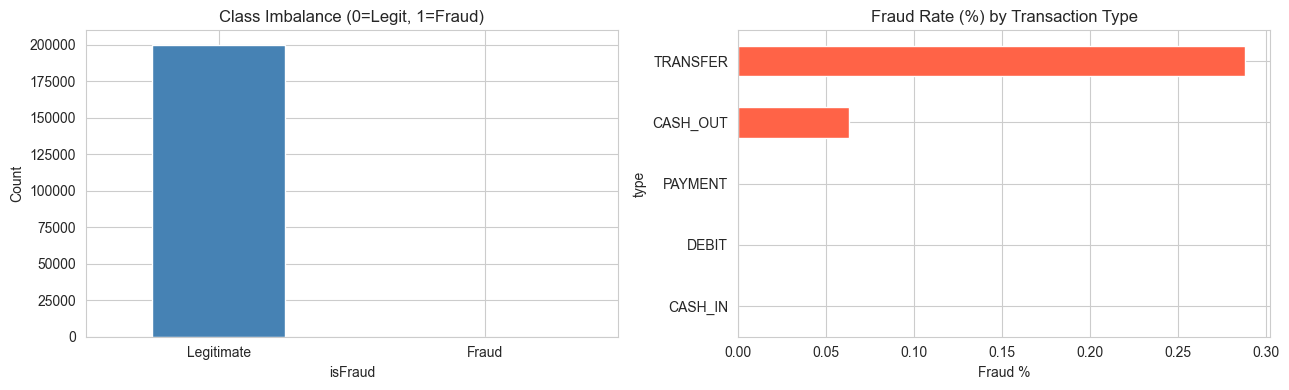


Fraud only in these types:
type
TRANSFER    47
CASH_OUT    46
Name: count, dtype: int64


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df["isFraud"].value_counts().plot(
    kind="bar", ax=axes[0], color=["steelblue", "tomato"], edgecolor="white")
axes[0].set_title("Class Imbalance (0=Legit, 1=Fraud)")
axes[0].set_xticklabels(["Legitimate", "Fraud"], rotation=0)
axes[0].set_ylabel("Count")

fraud_by_type = df.groupby("type")["isFraud"].mean() * 100
fraud_by_type.sort_values().plot(kind="barh", ax=axes[1], color="tomato")
axes[1].set_title("Fraud Rate (%) by Transaction Type")
axes[1].set_xlabel("Fraud %")
plt.tight_layout()
plt.show()

print("\nFraud only in these types:")
print(df[df["isFraud"] == 1]["type"].value_counts())

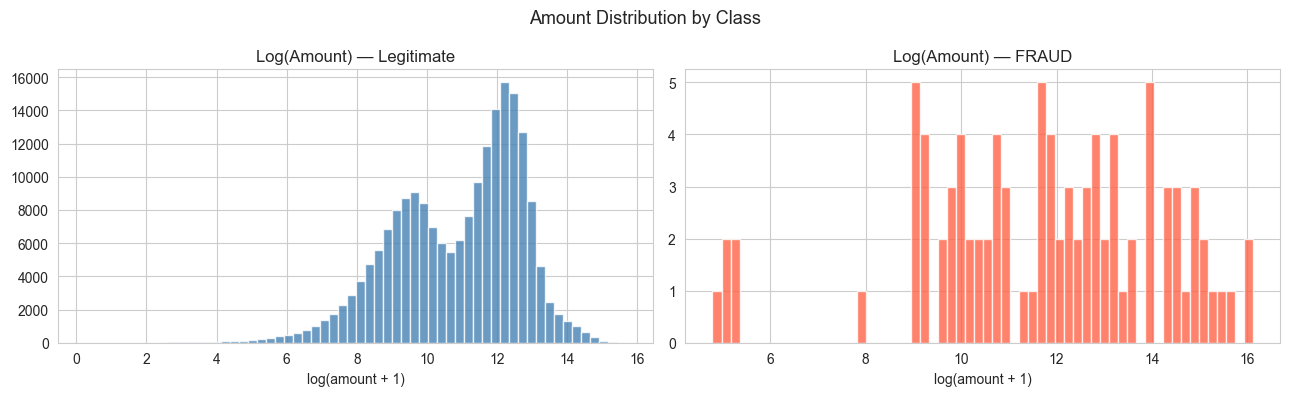

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for label, color, ax in zip([0, 1], ["steelblue", "tomato"], axes):
    subset = df[df["isFraud"] == label]["amount"]
    np.log1p(subset).hist(bins=60, ax=ax, color=color, alpha=0.8)
    ax.set_title(f"Log(Amount) — {'Legitimate' if label==0 else 'FRAUD'}")
    ax.set_xlabel("log(amount + 1)")
plt.suptitle("Amount Distribution by Class", fontsize=13)
plt.tight_layout()
plt.show()

## Phase 4 — Data Cleaning

In [7]:
numerical_cols = ["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest"]

df = df.drop_duplicates()
df.drop(columns=["nameOrig", "nameDest", "isFlaggedFraud"], inplace=True, errors="ignore")

print(f"Shape after cleaning : {df.shape}")
print("Remaining columns    :", df.columns.tolist())

Shape after cleaning : (200000, 8)
Remaining columns    : ['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud']


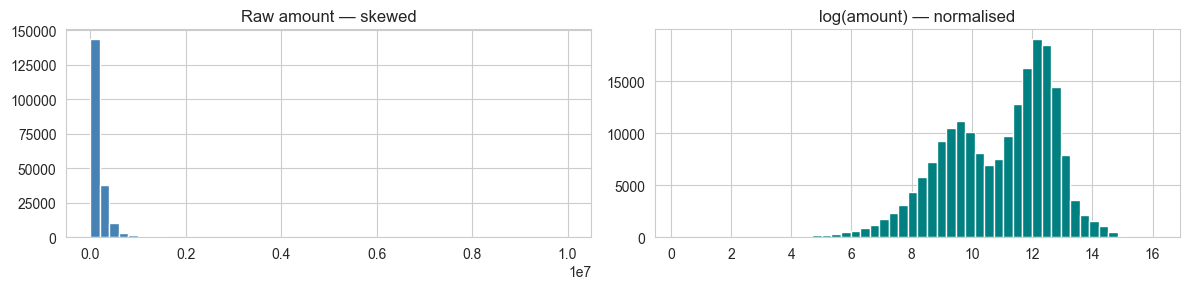

Log-transformed columns created.


In [8]:
for col in numerical_cols:
    df[f"log_{col}"] = np.log1p(df[col])

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
df["amount"].hist(bins=50, ax=axes[0], color="steelblue")
axes[0].set_title("Raw amount — skewed")
df["log_amount"].hist(bins=50, ax=axes[1], color="teal")
axes[1].set_title("log(amount) — normalised")
plt.tight_layout()
plt.show()
print("Log-transformed columns created.")

## Phase 5 — Feature Engineering (Objective 2)

In [9]:
df["orig_balance_drop"] = df["log_oldbalanceOrg"]  - df["log_newbalanceOrig"]
df["dest_balance_gain"] = df["log_newbalanceDest"] - df["log_oldbalanceDest"]
df["balance_mismatch"]  = df["orig_balance_drop"]  - df["dest_balance_gain"]

df["sender_zero_after"]       = (df["newbalanceOrig"] == 0).astype(int)
df["dest_zero_before"]        = (df["oldbalanceDest"] == 0).astype(int)
df["amount_to_balance_ratio"] = df["amount"] / (df["oldbalanceOrg"] + 1)

le = LabelEncoder()
df["type_encoded"] = le.fit_transform(df["type"])
type_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Transaction type encoding:", type_mapping)

df["hour_of_day"] = df["step"] % 24

q95 = df["amount"].quantile(0.95)
df["is_high_amount"] = (df["amount"] > q95).astype(int)
print(f"High-amount threshold (95th pct): {q95:,.0f}")
print("\nFeature engineering complete.")

Transaction type encoding: {'CASH_IN': 0, 'CASH_OUT': 1, 'DEBIT': 2, 'PAYMENT': 3, 'TRANSFER': 4}
High-amount threshold (95th pct): 545,454

Feature engineering complete.


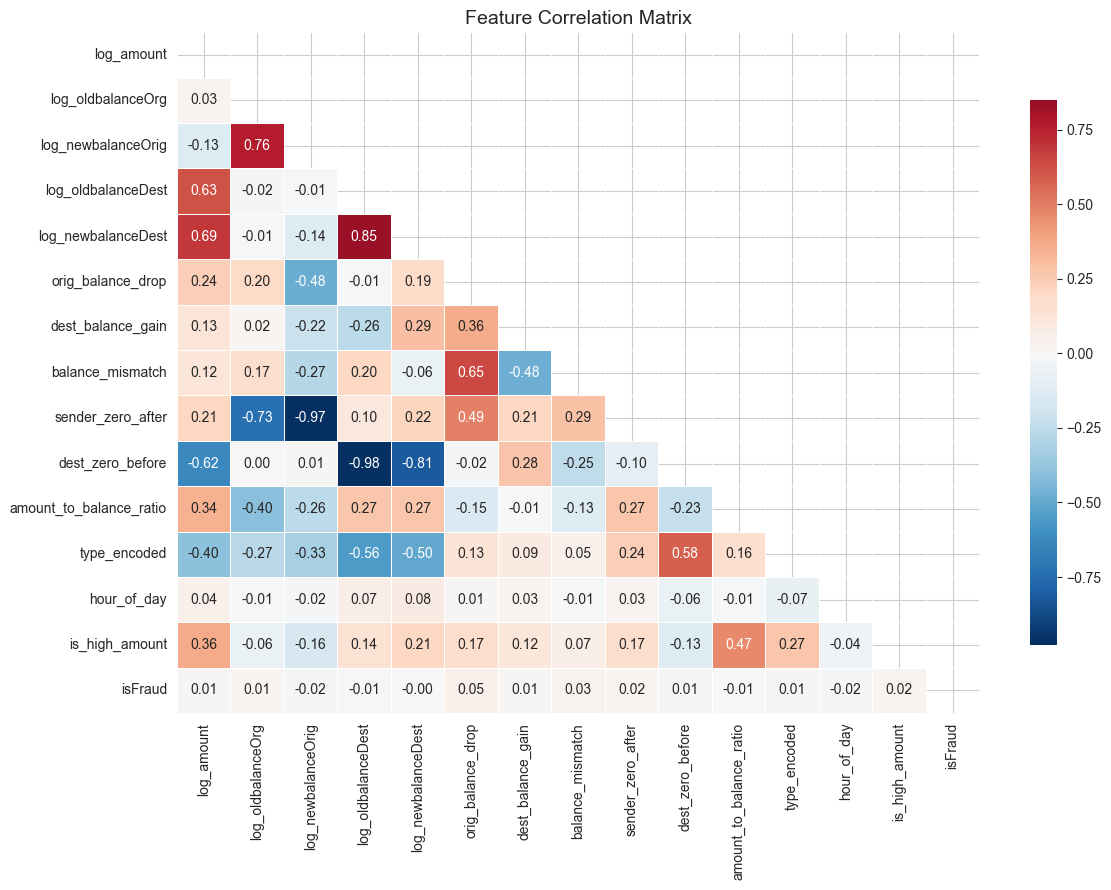

In [10]:
feature_cols = [
    "log_amount","log_oldbalanceOrg","log_newbalanceOrig",
    "log_oldbalanceDest","log_newbalanceDest",
    "orig_balance_drop","dest_balance_gain","balance_mismatch",
    "sender_zero_after","dest_zero_before","amount_to_balance_ratio",
    "type_encoded","hour_of_day","is_high_amount","isFraud"
]

corr = df[feature_cols].corr()
plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, linewidths=0.4, cbar_kws={"shrink": 0.8})
plt.title("Feature Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()

## Phase 6 — Feature Selection & Train/Test Split

In [11]:
FEATURES = [
    "log_amount","log_oldbalanceOrg","log_newbalanceOrig",
    "log_oldbalanceDest","log_newbalanceDest",
    "orig_balance_drop","dest_balance_gain","balance_mismatch",
    "sender_zero_after","dest_zero_before","amount_to_balance_ratio",
    "type_encoded","hour_of_day","is_high_amount"
]

X = df[FEATURES]
y = df["isFraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set  : {X_train.shape[0]:,} samples")
print(f"Test set      : {X_test.shape[0]:,} samples")
print(f"\nFraud in train: {y_train.sum():,} ({y_train.mean()*100:.2f}%)")
print(f"Fraud in test : {y_test.sum():,}  ({y_test.mean()*100:.2f}%)")

Training set  : 160,000 samples
Test set      : 40,000 samples

Fraud in train: 74 (0.05%)
Fraud in test : 19  (0.05%)


In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print(f"Before SMOTE — Fraud: {y_train.sum():,}  Legit: {(y_train==0).sum():,}")
print(f"After  SMOTE — Fraud: {y_train_sm.sum():,}  Legit: {(y_train_sm==0).sum():,}")
print("SMOTE applied — classes balanced for training.")

Before SMOTE — Fraud: 74  Legit: 159,926
After  SMOTE — Fraud: 159,926  Legit: 159,926
SMOTE applied — classes balanced for training.


## Phase 7 — Model Training (Objective 3)
Training 6 models: Naïve Bayes, SVM (fast/linear), Random Forest, Gradient Boosting, XGBoost, LightGBM

> **Note:** SVM uses `max_iter=500` and a small subsample so it finishes in seconds, not hours.

In [13]:
# ── SVM uses a 10% subsample — it's too slow on large data ───────────────
svm_idx = np.random.choice(len(X_train_sm),
                            size=int(len(X_train_sm) * 0.10),
                            replace=False)
X_svm = X_train_sm[svm_idx]
y_svm = y_train_sm[svm_idx]
print(f"SVM training subset: {len(X_svm):,} samples (10% — keeps it fast)")

models = {
    "Naive Bayes"            : GaussianNB(),
    "SVM"                    : SVC(kernel="linear", probability=True,
                                   C=1.0, random_state=42, max_iter=500),
    "Random Forest"          : RandomForestClassifier(n_estimators=100, max_depth=12,
                                                       n_jobs=-1, random_state=42),
    "Gradient Boosted Trees" : GradientBoostingClassifier(n_estimators=100, max_depth=5,
                                                           learning_rate=0.1, random_state=42),
    "XGBoost"                : XGBClassifier(n_estimators=100, max_depth=6,
                                              learning_rate=0.1, use_label_encoder=False,
                                              eval_metric="logloss", random_state=42, n_jobs=-1),
    "LightGBM"               : lgb.LGBMClassifier(n_estimators=100, max_depth=6,
                                                    learning_rate=0.1, random_state=42,
                                                    n_jobs=-1, verbose=-1),
}

results        = []
trained_models = {}

for name, model in models.items():
    print(f"\n Training: {name} ...")
    t0 = time.time()

    # SVM trains on subsample only
    if name == "SVM":
        model.fit(X_svm, y_svm)
    else:
        model.fit(X_train_sm, y_train_sm)

    elapsed = time.time() - t0
    y_pred  = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    auc     = roc_auc_score(y_test, y_proba)
    report  = classification_report(y_test, y_pred,
                                     target_names=["Legitimate","Fraud"],
                                     output_dict=True)

    results.append({"model": name, "object": model,
                    "report": report, "auc": auc,
                    "y_pred": y_pred, "y_proba": y_proba})
    trained_models[name] = model

    print(f" Done in {elapsed:.1f}s  |  ROC-AUC: {auc:.4f}  |  "
          f"Fraud F1: {report['Fraud']['f1-score']:.4f}")

print("\n All 6 models trained!")

SVM training subset: 31,985 samples (10% — keeps it fast)

 Training: Naive Bayes ...
 Done in 0.2s  |  ROC-AUC: 0.9057  |  Fraud F1: 0.0041

 Training: SVM ...
 Done in 7.2s  |  ROC-AUC: 0.8663  |  Fraud F1: 0.0029

 Training: Random Forest ...
 Done in 13.2s  |  ROC-AUC: 0.9297  |  Fraud F1: 0.1013

 Training: Gradient Boosted Trees ...
 Done in 285.5s  |  ROC-AUC: 0.9398  |  Fraud F1: 0.1258

 Training: XGBoost ...
 Done in 2.3s  |  ROC-AUC: 0.9220  |  Fraud F1: 0.3291

 Training: LightGBM ...
 Done in 2.6s  |  ROC-AUC: 0.9377  |  Fraud F1: 0.9444

 All 6 models trained!


## Phase 8 — Model Evaluation (Objective 4)

In [14]:
for r in results:
    print("=" * 65)
    print(f"  MODEL: {r['model']}")
    print("=" * 65)
    rep = r["report"]
    print(f"  Accuracy         : {rep['accuracy']:.4f}")
    print(f"  Precision (Fraud): {rep['Fraud']['precision']:.4f}")
    print(f"  Recall    (Fraud): {rep['Fraud']['recall']:.4f}")
    print(f"  F1-Score  (Fraud): {rep['Fraud']['f1-score']:.4f}")
    print(f"  ROC-AUC          : {r['auc']:.4f}")
    print()

  MODEL: Naive Bayes
  Accuracy         : 0.7805
  Precision (Fraud): 0.0020
  Recall    (Fraud): 0.9474
  F1-Score  (Fraud): 0.0041
  ROC-AUC          : 0.9057

  MODEL: SVM
  Accuracy         : 0.6940
  Precision (Fraud): 0.0015
  Recall    (Fraud): 0.9474
  F1-Score  (Fraud): 0.0029
  ROC-AUC          : 0.8663

  MODEL: Random Forest
  Accuracy         : 0.9947
  Precision (Fraud): 0.0550
  Recall    (Fraud): 0.6316
  F1-Score  (Fraud): 0.1013
  ROC-AUC          : 0.9297

  MODEL: Gradient Boosted Trees
  Accuracy         : 0.9965
  Precision (Fraud): 0.0714
  Recall    (Fraud): 0.5263
  F1-Score  (Fraud): 0.1258
  ROC-AUC          : 0.9398

  MODEL: XGBoost
  Accuracy         : 0.9987
  Precision (Fraud): 0.2167
  Recall    (Fraud): 0.6842
  F1-Score  (Fraud): 0.3291
  ROC-AUC          : 0.9220

  MODEL: LightGBM
  Accuracy         : 1.0000
  Precision (Fraud): 1.0000
  Recall    (Fraud): 0.8947
  F1-Score  (Fraud): 0.9444
  ROC-AUC          : 0.9377



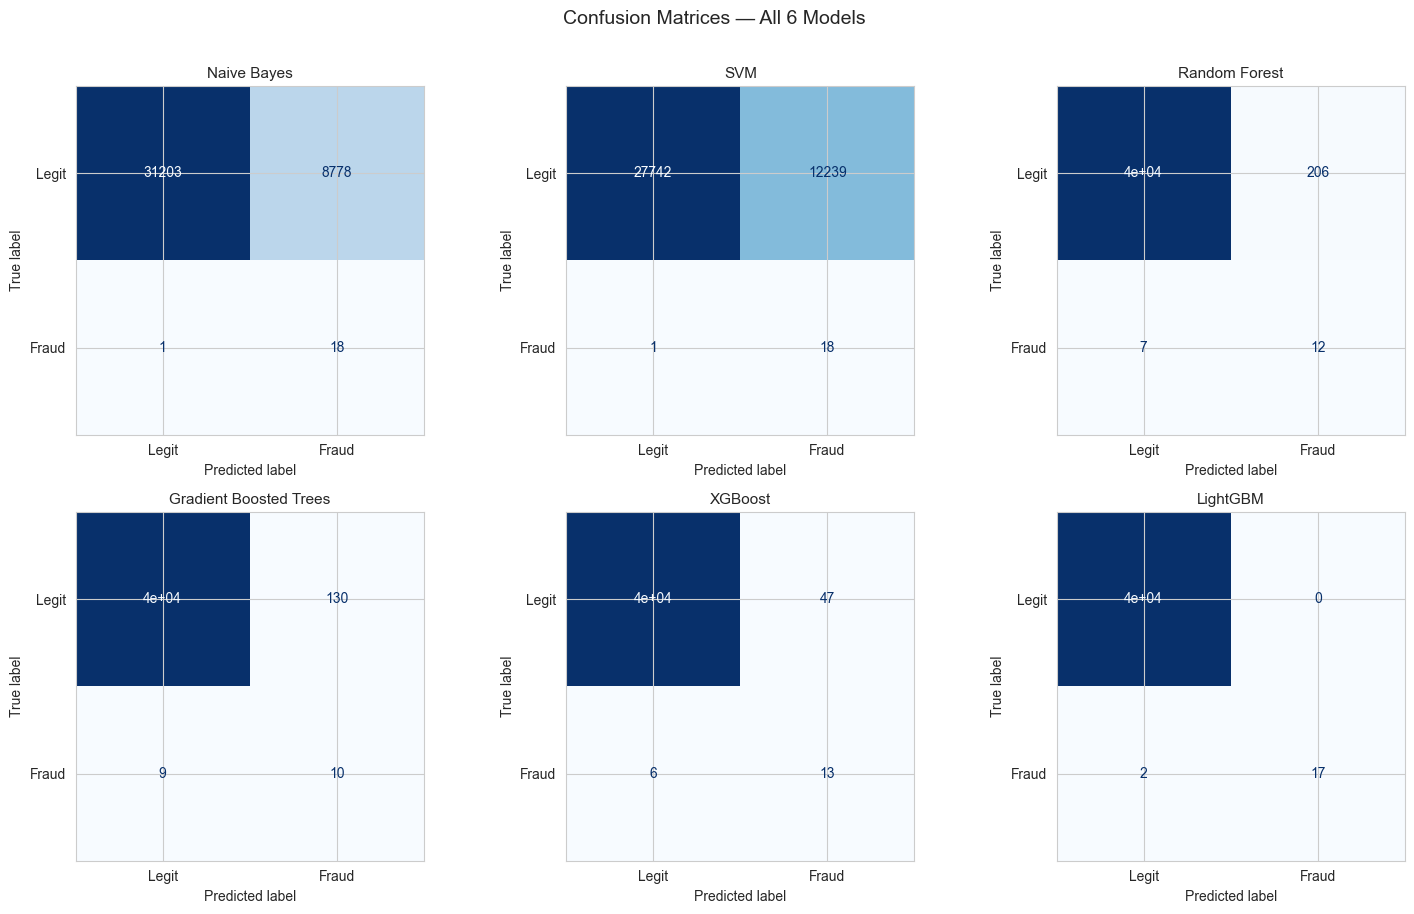

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, r in zip(axes.flat, results):
    cm = confusion_matrix(y_test, r["y_pred"])
    disp = ConfusionMatrixDisplay(cm, display_labels=["Legit", "Fraud"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(r["model"], fontsize=11)
plt.suptitle("Confusion Matrices — All 6 Models", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

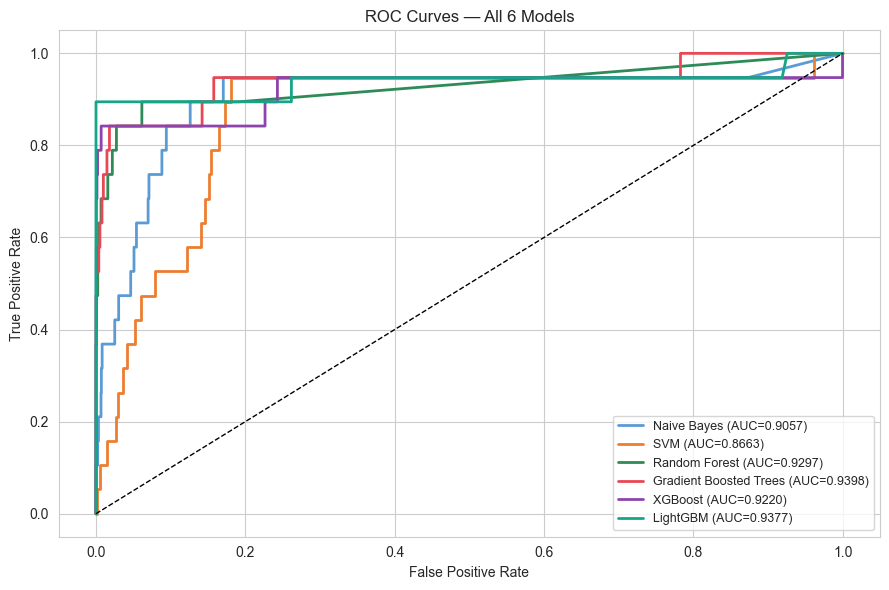

In [16]:
plt.figure(figsize=(9, 6))
colors = ["#5B9BD5","#ED7D31","#2E8B57","#E84855","#8E44AD","#17A589"]
for r, color in zip(results, colors):
    fpr, tpr, _ = roc_curve(y_test, r["y_proba"])
    plt.plot(fpr, tpr, lw=2, color=color,
             label=f"{r['model']} (AUC={r['auc']:.4f})")
plt.plot([0,1],[0,1],"k--", lw=1)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All 6 Models")
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

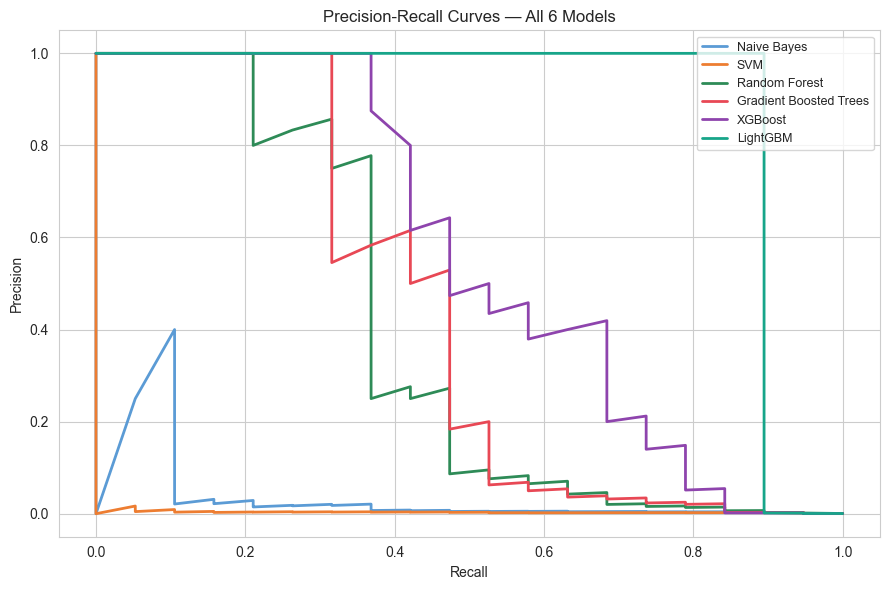

In [17]:
plt.figure(figsize=(9, 6))
for r, color in zip(results, colors):
    prec, rec, _ = precision_recall_curve(y_test, r["y_proba"])
    plt.plot(rec, prec, lw=2, color=color, label=r["model"])
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision-Recall Curves — All 6 Models")
plt.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

## Phase 9 — Model Comparison (Objective 6)

In [18]:
rows = []
for r in results:
    rep = r["report"]
    rows.append({
        "Model"           : r["model"],
        "Accuracy"        : round(rep["accuracy"], 4),
        "Fraud Precision" : round(rep["Fraud"]["precision"], 4),
        "Fraud Recall"    : round(rep["Fraud"]["recall"], 4),
        "Fraud F1"        : round(rep["Fraud"]["f1-score"], 4),
        "ROC-AUC"         : round(r["auc"], 4),
    })

comparison_df = pd.DataFrame(rows).set_index("Model")
print("\n" + "=" * 72)
print("  FINAL MODEL COMPARISON — ALL 6 ALGORITHMS")
print("=" * 72)
print(comparison_df.to_string())
print("=" * 72)
print("\n* Fraud Recall = % of actual fraud transactions correctly detected.")
print("* Prioritise Fraud F1 — balances precision and recall for deployment.")


  FINAL MODEL COMPARISON — ALL 6 ALGORITHMS
                        Accuracy  Fraud Precision  Fraud Recall  Fraud F1  ROC-AUC
Model                                                                             
Naive Bayes               0.7805           0.0020        0.9474    0.0041   0.9057
SVM                       0.6940           0.0015        0.9474    0.0029   0.8663
Random Forest             0.9947           0.0550        0.6316    0.1013   0.9297
Gradient Boosted Trees    0.9965           0.0714        0.5263    0.1258   0.9398
XGBoost                   0.9987           0.2167        0.6842    0.3291   0.9220
LightGBM                  1.0000           1.0000        0.8947    0.9444   0.9377

* Fraud Recall = % of actual fraud transactions correctly detected.
* Prioritise Fraud F1 — balances precision and recall for deployment.


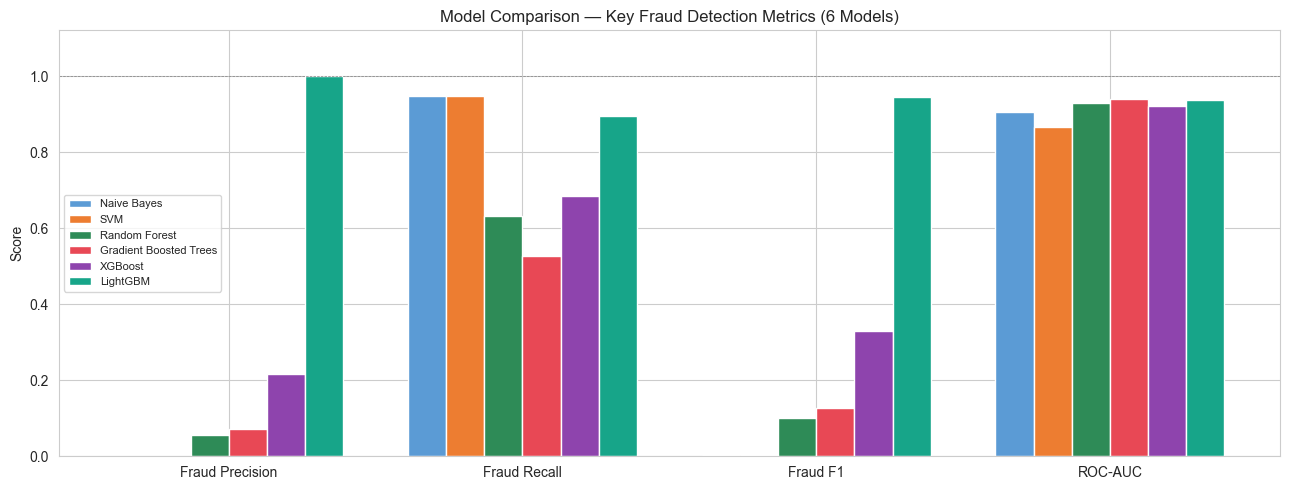

In [19]:
metrics    = ["Fraud Precision","Fraud Recall","Fraud F1","ROC-AUC"]
x          = np.arange(len(metrics))
width      = 0.13
colors_bar = ["#5B9BD5","#ED7D31","#2E8B57","#E84855","#8E44AD","#17A589"]

fig, ax = plt.subplots(figsize=(13, 5))
for i, (idx, row) in enumerate(comparison_df.iterrows()):
    vals = [float(row[m]) for m in metrics]
    ax.bar(x + i * width, vals, width, label=idx, color=colors_bar[i])

ax.set_xticks(x + width * 2.5)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score")
ax.set_title("Model Comparison — Key Fraud Detection Metrics (6 Models)")
ax.legend(fontsize=8)
ax.axhline(1.0, color="grey", linewidth=0.5, linestyle="--")
plt.tight_layout()
plt.show()

## Phase 10 — Feature Importance (Tree Models)

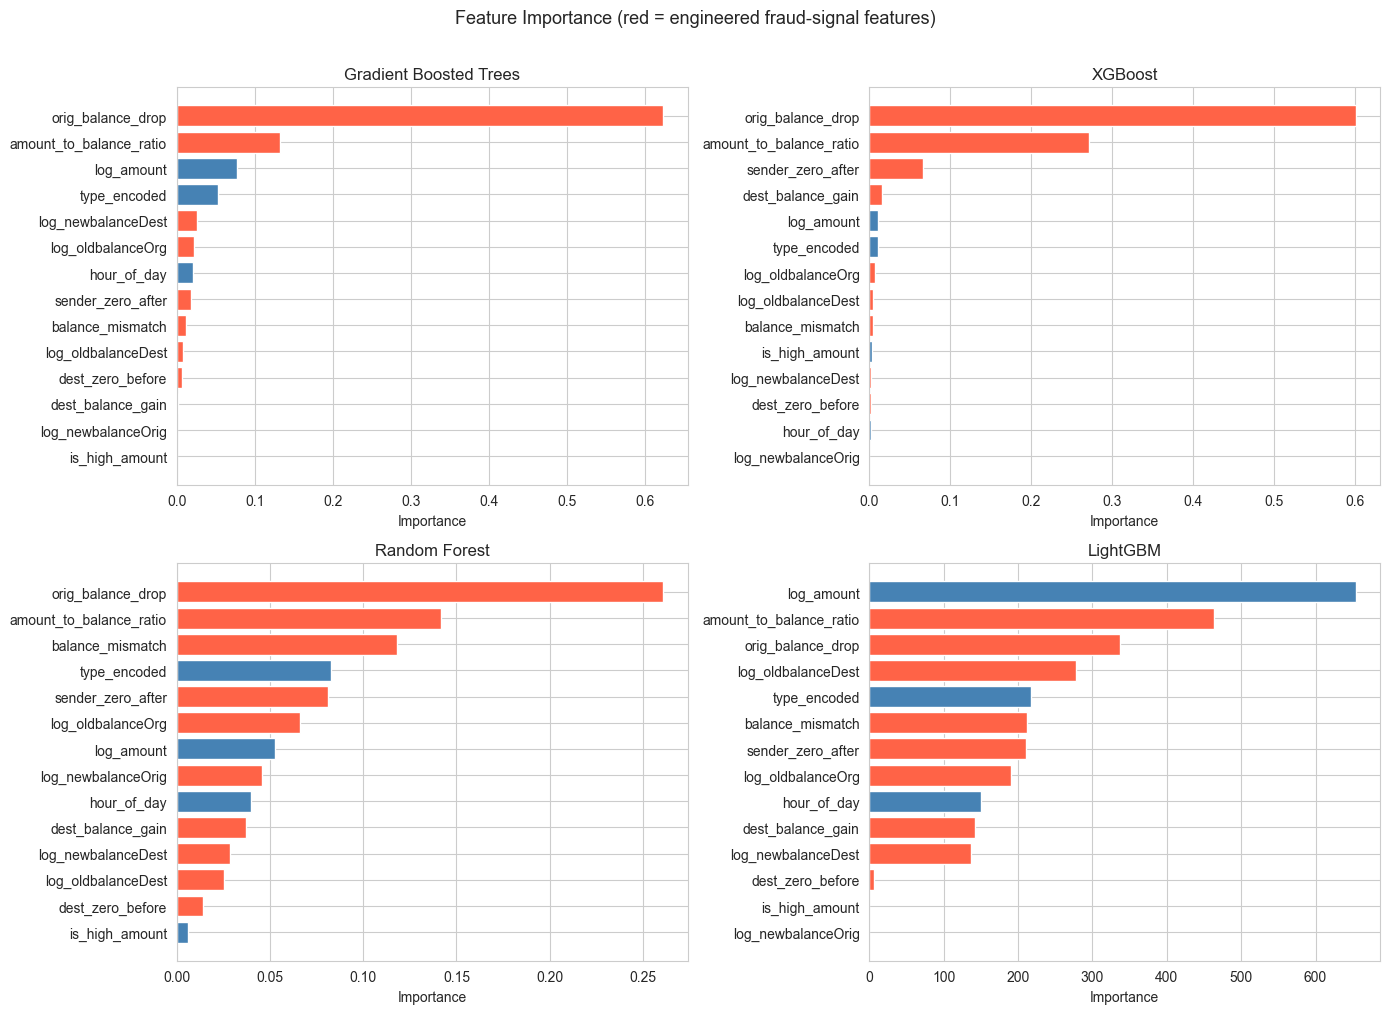

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
tree_model_names = ["Gradient Boosted Trees","XGBoost","Random Forest","LightGBM"]
tree_objs        = [trained_models[n] for n in tree_model_names]

for ax, name, model in zip(axes.flat, tree_model_names, tree_objs):
    imps    = model.feature_importances_
    feat_df = pd.DataFrame({"feature": FEATURES, "importance": imps})
    feat_df = feat_df.sort_values("importance", ascending=True)
    bar_colors = [
        "tomato" if any(k in f for k in ["balance","zero","mismatch","ratio"])
        else "steelblue" for f in feat_df["feature"]
    ]
    ax.barh(feat_df["feature"], feat_df["importance"], color=bar_colors)
    ax.set_title(name)
    ax.set_xlabel("Importance")

plt.suptitle("Feature Importance (red = engineered fraud-signal features)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Phase 11 — Threshold Tuning (Best Model)

Best model by Fraud F1: LightGBM
Optimal threshold : 0.31
Best Fraud F1     : 0.9444


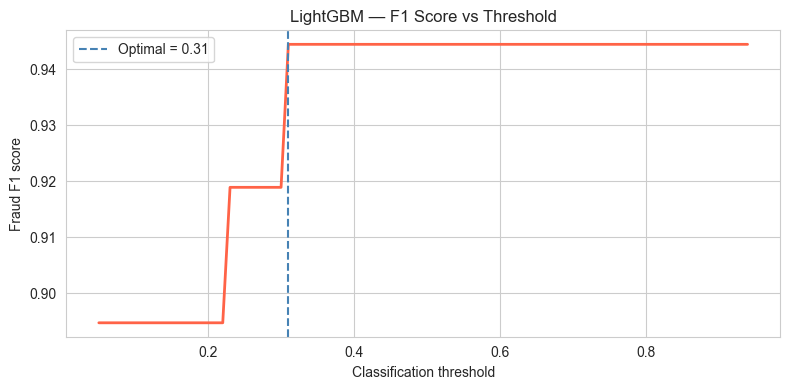


Report at optimal threshold = 0.31:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     39981
       Fraud       1.00      0.89      0.94        19

    accuracy                           1.00     40000
   macro avg       1.00      0.95      0.97     40000
weighted avg       1.00      1.00      1.00     40000



In [21]:
best_result = max(results, key=lambda r: r["report"]["Fraud"]["f1-score"])
best_name   = best_result["model"]
best_obj    = best_result["object"]
print(f"Best model by Fraud F1: {best_name}")

y_proba_best = best_obj.predict_proba(X_test_scaled)[:, 1]
thresh_range = np.arange(0.05, 0.95, 0.01)
f1_list      = [f1_score(y_test, (y_proba_best >= t).astype(int), zero_division=0)
                for t in thresh_range]

optimal_threshold = thresh_range[np.argmax(f1_list)]
print(f"Optimal threshold : {optimal_threshold:.2f}")
print(f"Best Fraud F1     : {max(f1_list):.4f}")

plt.figure(figsize=(8, 4))
plt.plot(thresh_range, f1_list, color="tomato", lw=2)
plt.axvline(optimal_threshold, color="steelblue", linestyle="--", lw=1.5,
            label=f"Optimal = {optimal_threshold:.2f}")
plt.xlabel("Classification threshold"); plt.ylabel("Fraud F1 score")
plt.title(f"{best_name} — F1 Score vs Threshold")
plt.legend(); plt.tight_layout(); plt.show()

y_pred_opt = (y_proba_best >= optimal_threshold).astype(int)
print(f"\nReport at optimal threshold = {optimal_threshold:.2f}:")
print(classification_report(y_test, y_pred_opt, target_names=["Legitimate","Fraud"]))

## Phase 12 — Real-Time Fraud Alert Integration (Objective 5)

In [22]:
def predict_fraud(transaction: dict, model, scaler, threshold: float) -> dict:
    feature_order = [
        "log_amount","log_oldbalanceOrg","log_newbalanceOrig",
        "log_oldbalanceDest","log_newbalanceDest",
        "orig_balance_drop","dest_balance_gain","balance_mismatch",
        "sender_zero_after","dest_zero_before","amount_to_balance_ratio",
        "type_encoded","hour_of_day","is_high_amount"
    ]
    vec   = np.array([[transaction.get(f, 0) for f in feature_order]])
    vec_s = scaler.transform(vec)
    score = model.predict_proba(vec_s)[0][1]

    if score >= threshold:
        risk, action = "HIGH", "BLOCK_AND_FACE_VERIFY"
    elif score >= threshold * 0.6:
        risk, action = "MEDIUM", "FLAG_FOR_REVIEW"
    else:
        risk, action = "LOW", "ALLOW"

    return {"fraud_score": round(float(score), 4), "risk_level": risk,
            "action": action, "is_fraud": score >= threshold,
            "threshold_used": round(float(threshold), 2)}

demo_txns = [
    # Legitimate
    {"log_amount":6.9,"log_oldbalanceOrg":12.2,"log_newbalanceOrig":11.5,
     "log_oldbalanceDest":9.0,"log_newbalanceDest":9.8,
     "orig_balance_drop":0.7,"dest_balance_gain":0.8,"balance_mismatch":-0.1,
     "sender_zero_after":0,"dest_zero_before":0,"amount_to_balance_ratio":0.05,
     "type_encoded":4,"hour_of_day":10,"is_high_amount":0},
    # Fraud: drain to zero
    {"log_amount":12.5,"log_oldbalanceOrg":12.5,"log_newbalanceOrig":0.0,
     "log_oldbalanceDest":0.0,"log_newbalanceDest":12.5,
     "orig_balance_drop":12.5,"dest_balance_gain":12.5,"balance_mismatch":0.0,
     "sender_zero_after":1,"dest_zero_before":1,"amount_to_balance_ratio":0.99,
     "type_encoded":1,"hour_of_day":3,"is_high_amount":1},
    # Medium risk
    {"log_amount":10.5,"log_oldbalanceOrg":11.0,"log_newbalanceOrig":10.2,
     "log_oldbalanceDest":5.0,"log_newbalanceDest":5.8,
     "orig_balance_drop":0.8,"dest_balance_gain":0.8,"balance_mismatch":0.0,
     "sender_zero_after":0,"dest_zero_before":0,"amount_to_balance_ratio":0.4,
     "type_encoded":4,"hour_of_day":23,"is_high_amount":1},
]

print("=" * 60)
print("  REAL-TIME FRAUD DETECTION DEMO")
print("=" * 60)
for i, txn in enumerate(demo_txns, 1):
    result = predict_fraud(txn, best_obj, scaler, optimal_threshold)
    status = "FRAUD ALERT" if result["is_fraud"] else "ALLOWED"
    print(f"\nTransaction {i}:")
    print(f"  Score    : {result['fraud_score']}")
    print(f"  Risk     : {result['risk_level']}")
    print(f"  Action   : {result['action']}")
    print(f"  Decision : {status}")

  REAL-TIME FRAUD DETECTION DEMO

Transaction 1:
  Score    : 0.0
  Risk     : LOW
  Action   : ALLOW
  Decision : ALLOWED

Transaction 2:
  Score    : 1.0
  Risk     : HIGH
  Action   : BLOCK_AND_FACE_VERIFY
  Decision : FRAUD ALERT

Transaction 3:
  Score    : 0.0
  Risk     : LOW
  Action   : ALLOW
  Decision : ALLOWED


## Phase 13 — Cost-Benefit Analysis (Rwanda Context)

In [23]:
AVG_FRAUD = 50_000
FP_COST   =    500
n_fraud   = int(y_test.sum())

print("=" * 68)
print("  COST-BENEFIT ANALYSIS — ALL 6 MODELS (Rwanda context)")
print("=" * 68)

summary = []
for r in results:
    rep       = r["report"]
    recall    = rep["Fraud"]["recall"]
    precision = rep["Fraud"]["precision"]
    caught    = int(recall * n_fraud)
    missed    = n_fraud - caught
    fp        = int(caught * (1 - precision) / precision) if precision > 0 else 0
    saved     = caught * AVG_FRAUD
    fp_dmg    = fp * FP_COST
    net       = saved - fp_dmg
    summary.append({"Model": r["model"], "Net (M RWF)": round(net / 1e6, 2),
                    "Caught": caught, "Missed": missed})
    print(f"\n  {r['model']}")
    print(f"    Caught  : {caught:>6,}  -> {saved/1e6:.2f}M RWF protected")
    print(f"    Missed  : {missed:>6,}  -> {missed*AVG_FRAUD/1e6:.2f}M RWF lost")
    print(f"    FP cost :          -> {fp_dmg/1e3:.1f}K RWF")
    print(f"    NET     :          -> {net/1e6:.2f}M RWF")

print("\n" + "=" * 68)
winner = max(summary, key=lambda x: x["Net (M RWF)"])
print(f"  Best model by net value : {winner['Model']}")
print(f"  Net financial protection: {winner['Net (M RWF)']}M RWF")
print("=" * 68)

  COST-BENEFIT ANALYSIS — ALL 6 MODELS (Rwanda context)

  Naive Bayes
    Caught  :     18  -> 0.90M RWF protected
    Missed  :      1  -> 0.05M RWF lost
    FP cost :          -> 4389.0K RWF
    NET     :          -> -3.49M RWF

  SVM
    Caught  :     18  -> 0.90M RWF protected
    Missed  :      1  -> 0.05M RWF lost
    FP cost :          -> 6119.5K RWF
    NET     :          -> -5.22M RWF

  Random Forest
    Caught  :     12  -> 0.60M RWF protected
    Missed  :      7  -> 0.35M RWF lost
    FP cost :          -> 103.0K RWF
    NET     :          -> 0.50M RWF

  Gradient Boosted Trees
    Caught  :     10  -> 0.50M RWF protected
    Missed  :      9  -> 0.45M RWF lost
    FP cost :          -> 65.0K RWF
    NET     :          -> 0.43M RWF

  XGBoost
    Caught  :     13  -> 0.65M RWF protected
    Missed  :      6  -> 0.30M RWF lost
    FP cost :          -> 23.5K RWF
    NET     :          -> 0.63M RWF

  LightGBM
    Caught  :     17  -> 0.85M RWF protected
    Missed  :      

## Phase 14 — Save Best Model for Deployment

In [24]:
best_result = max(results, key=lambda r: r["report"]["Fraud"]["f1-score"])
best_model  = best_result["object"]
best_name   = best_result["model"]

print(f"Saving best model: {best_name}")

joblib.dump(best_model, "fraud_best_model.pkl")
joblib.dump(scaler,     "fraud_scaler.pkl")

config = {
    "best_model" : best_name,
    "threshold"  : round(float(optimal_threshold), 2),
    "features"   : FEATURES,
    "fraud_f1"   : round(best_result["report"]["Fraud"]["f1-score"], 4),
    "roc_auc"    : round(best_result["auc"], 4),
}
with open("fraud_config.json", "w") as f:
    json.dump(config, f, indent=2)

print("\nFiles saved:")
print("  fraud_best_model.pkl")
print("  fraud_scaler.pkl")
print("  fraud_config.json")
print("\nConfig:")
print(json.dumps(config, indent=2))

Saving best model: LightGBM

Files saved:
  fraud_best_model.pkl
  fraud_scaler.pkl
  fraud_config.json

Config:
{
  "best_model": "LightGBM",
  "threshold": 0.31,
  "features": [
    "log_amount",
    "log_oldbalanceOrg",
    "log_newbalanceOrig",
    "log_oldbalanceDest",
    "log_newbalanceDest",
    "orig_balance_drop",
    "dest_balance_gain",
    "balance_mismatch",
    "sender_zero_after",
    "dest_zero_before",
    "amount_to_balance_ratio",
    "type_encoded",
    "hour_of_day",
    "is_high_amount"
  ],
  "fraud_f1": 0.9444,
  "roc_auc": 0.9377
}


## Phase 15 — Live Test on Your Real Users
Tests the saved model on your actual users from `mobile_money_users.db` — exactly what the Flask app does.

In [25]:
import sys
sys.path.insert(0, os.getcwd())

from fraud_detection import RealTimeFraudDetector
import sqlite3

detector = RealTimeFraudDetector(db_path="mobile_money_users.db")
print(f"Model     : {detector.config.get('best_model')}")
print(f"Threshold : {detector.threshold}")
print(f"AUC-ROC   : {detector.config.get('roc_auc')}")
print(f"Fraud F1  : {detector.config.get('fraud_f1')}")

[FraudDetector] ML model loaded: LightGBM | threshold=0.31
Model     : LightGBM
Threshold : 0.31
AUC-ROC   : 0.9377
Fraud F1  : 0.9444


In [26]:
conn = sqlite3.connect("mobile_money_users.db")
c = conn.cursor()
c.execute("SELECT phone_number, full_name, account_balance FROM users WHERE is_active = 1")
users = c.fetchall()
conn.close()

print("Your real users:")
for u in users:
    print(f"  {u[1]} ({u[0]}) — Balance: {u[2]:,.0f} RWF")

Your real users:
  UWINEZA Eric (+250783287066) — Balance: 50,700 RWF
  Ruhamo Rosa (+250780000000) — Balance: 28,440 RWF


In [27]:
s_phone, s_name, s_balance = users[0]
r_phone = users[1][0] if len(users) > 1 else users[0][0]

tests = [
    ("NORMAL  — 5% of balance",     round(s_balance * 0.05)),
    ("NORMAL  — 20% of balance",    round(s_balance * 0.20)),
    ("NORMAL  — 50% of balance",    round(s_balance * 0.50)),
    ("FRAUD   — drains full 100%",  s_balance),
    ("FRAUD   — 2x above balance",  round(s_balance * 2)),
]

print(f"\n{'='*65}")
print(f"  Sender: {s_name}  |  Balance: {s_balance:,.0f} RWF")
print(f"  Model : {detector.config.get('best_model')}  |  Threshold: {detector.threshold}")
print(f"{'='*65}")

scores_list = []
labels_list = []

for label, amount in tests:
    r = detector.evaluate_transaction(s_phone, amount, r_phone, "MTN")
    icon = "✅" if r['action']=="ALLOW" else ("⚠️ " if r['action']=="REQUIRE_FACE" else "🚨")
    scores_list.append(r['ml_score'])
    labels_list.append(label.split("—")[1].strip())
    print(f"\n{icon} {label}")
    print(f"   Amount   : {amount:>10,.0f} RWF")
    print(f"   ML Score : {r['ml_score']:.4f}")
    print(f"   Risk     : {r['risk_level']}")
    print(f"   Action   : {r['action']}")


  Sender: UWINEZA Eric  |  Balance: 50,700 RWF
  Model : LightGBM  |  Threshold: 0.31

✅ NORMAL  — 5% of balance
   Amount   :      2,535 RWF
   ML Score : 0.0000
   Risk     : LOW
   Action   : ALLOW

✅ NORMAL  — 20% of balance
   Amount   :     10,140 RWF
   ML Score : 0.0000
   Risk     : LOW
   Action   : ALLOW

✅ NORMAL  — 50% of balance
   Amount   :     25,350 RWF
   ML Score : 0.0000
   Risk     : LOW
   Action   : ALLOW

🚨 [FRAUD ALERT] Phone: +250783287066 | Amount: 50,700 RWF | Score: 1.000 | Risk: HIGH | Action: REQUIRE_FACE. ML score=1.000


⚠️  FRAUD   — drains full 100%
   Amount   :     50,700 RWF
   ML Score : 1.0000
   Risk     : HIGH
   Action   : REQUIRE_FACE

✅ FRAUD   — 2x above balance
   Amount   :    101,400 RWF
   ML Score : 0.0000
   Risk     : LOW
   Action   : ALLOW


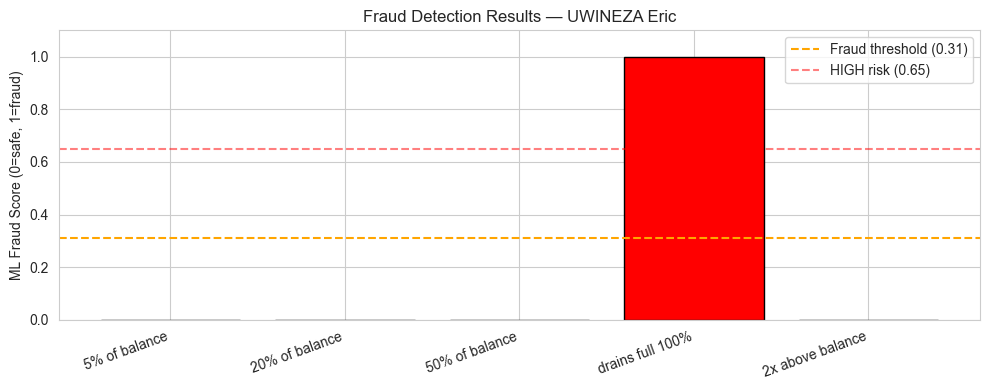


Green = ALLOW  (score < 0.31)
Red   = BLOCK / REQUIRE FACE  (score >= 0.31)


In [28]:
colors_v = ["green" if s < detector.threshold else "red" for s in scores_list]

plt.figure(figsize=(10, 4))
plt.bar(labels_list, scores_list, color=colors_v, edgecolor="black")
plt.axhline(y=detector.threshold, color="orange", linestyle="--",
            label=f"Fraud threshold ({detector.threshold})")
plt.axhline(y=0.65, color="red", linestyle="--", alpha=0.5, label="HIGH risk (0.65)")
plt.ylabel("ML Fraud Score (0=safe, 1=fraud)")
plt.title(f"Fraud Detection Results — {s_name}")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1.1)
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nGreen = ALLOW  (score < {detector.threshold})")
print(f"Red   = BLOCK / REQUIRE FACE  (score >= {detector.threshold})")